# Credit Risk Scoring for Bank GoodCredit
## 1. Introduction

Credit risk assessment is an important application of machine learning in the banking and financial sector. Banks and financial institutions need to identify customers who are likely to default before approving loans or extending additional credit.

This project develops a machine learning model to predict whether a customer is likely to be classified as a **bad-risk customer** based on their account information, enquiry history, demographic information, and payment behaviour.

The project combines data extraction, exploratory data analysis, feature engineering, machine learning, model evaluation, and risk ranking into a single end-to-end workflow.

---

## 2. Problem Statement

Traditional credit assessment methods often depend on manually defined rules and historical credit scoring methods. These approaches may not fully capture complex relationships between customer behaviour, account activity, credit utilization, and enquiry patterns.

The objective of this project is to develop a machine learning-based credit risk model that can:

- Identify customers with a higher probability of becoming bad-risk customers.
- Use historical account and enquiry information to generate meaningful predictive features.
- Handle class imbalance in the target variable.
- Rank customers according to their predicted risk.
- Evaluate model performance using industry-relevant metrics such as **AUC and Gini**.
- Compare model performance against a predefined benchmark.

---

## 3. Project Objectives

The major objectives of the project are:

1. Extract customer data from the banking database.
2. Perform exploratory data analysis on customer accounts, enquiries, and demographics.
3. Identify missing values and understand the structure of the datasets.
4. Engineer meaningful credit-risk features.
5. Combine information from multiple customer-level datasets.
6. Train a machine learning classification model.
7. Handle class imbalance using class weighting.
8. Evaluate the model using ROC-AUC and Gini coefficient.
9. Perform decile-based risk ranking.
10. Compare the model's Gini score with the given benchmark.
11. Generate model outputs and an evaluation report.

---

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
%matplotlib inline

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/eda_plots", exist_ok=True)

print("Environment ready.")


Environment ready.


## Database Connection and Data Extraction

In [2]:
DB_HOST = os.getenv("DB_HOST", "18.136.157.135")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "dm_team1")
DB_PASSWORD = os.getenv("DB_PASSWORD", "DM!$Team&279@20!")
DB_NAME = os.getenv("DB_NAME", "project_banking")

TABLES = ["Cust_Account", "Cust_Enquiry", "Cust_Demographics"]


def get_engine():
    url = (
        f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}"
        f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )
    return create_engine(
        url,
        connect_args={"connect_timeout": 10}
    )


def test_connection():
    try:
        engine = get_engine()
        with engine.connect() as conn:
            conn.execute(text("SELECT 1"))
        print("Database connection successful.")
        return True
    except Exception as e:
        print("Database connection failed.")
        print(e)
        return False


def extract_all(save_dir="data"):
    engine = get_engine()
    frames = {}

    for table in TABLES:
        print(f"Extracting {table}...")
        df = pd.read_sql(f"SELECT * FROM {table}", engine)

        df.to_csv(
            os.path.join(save_dir, f"{table}.csv"),
            index=False
        )

        print(f"  {len(df):,} rows saved.")
        frames[table] = df

    return frames


db_available = test_connection()

Database connection failed.
(pymysql.err.OperationalError) (2003, "Can't connect to MySQL server on '20!@18.136.157.135' ([Errno 11003] getaddrinfo failed)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [3]:
# --- Synthetic fallback (same schema) --------------------------
# Only runs if the real DB above isn't reachable, so you can build/test
# the whole pipeline offline and swap in real data later with zero code changes.

RNG = np.random.default_rng(42)
N_CUSTOMERS = 5000

def _random_dpd_string(length=24):
    buckets = ["000", "030", "060", "090", "XXX"]
    weights = [0.80, 0.08, 0.05, 0.03, 0.04]
    return "".join(RNG.choice(buckets, size=length, p=weights))

def generate_cust_account(customer_ids):
    rows = []
    for cust in customer_ids:
        for _ in range(RNG.integers(1, 4)):
            opened = pd.Timestamp("2015-01-01") + pd.Timedelta(days=int(RNG.integers(0, 2000)))
            last_paymt = opened + pd.Timedelta(days=int(RNG.integers(30, 1800)))
            rows.append({
                "customer_no": cust,
                "acct_type": RNG.choice(["Credit Card", "Personal Loan", "Auto Loan"]),
                "owner_indic": RNG.choice(["Individual", "Joint"]),
                "opened_dt": opened,
                "last_paymt_dt": last_paymt,
                "closed_dt": pd.NaT,
                "reporting_dt": last_paymt + pd.Timedelta(days=30),
                "high_credit_amt": round(float(RNG.uniform(5000, 500000)), 2),
                "cur_balance_amt": round(float(RNG.uniform(0, 400000)), 2),
                "amt_past_due": round(float(RNG.choice([0, 0, 0, RNG.uniform(500, 20000)])), 2),
                "paymenthistory1": _random_dpd_string(),
                "paymenthistory2": _random_dpd_string(),
                "creditlimit": round(float(RNG.uniform(10000, 300000)), 2),
                "cashlimit": round(float(RNG.uniform(1000, 50000)), 2),
                "rateofinterest": round(float(RNG.uniform(8, 24)), 2),
                "paymentfrequency": "Monthly",
                "actualpaymentamount": round(float(RNG.uniform(500, 20000)), 2),
            })
    return pd.DataFrame(rows)

def generate_cust_enquiry(customer_ids):
    rows = []
    purposes = ["Personal Loan", "Credit Card", "Auto Loan", "Home Loan", "Unsecured Others"]
    for cust in customer_ids:
        for _ in range(RNG.integers(0, 8)):
            enq_dt = pd.Timestamp("2023-01-01") - pd.Timedelta(days=int(RNG.integers(0, 730)))
            rows.append({
                "customer_no": cust,
                "enquiry_dt": enq_dt,
                "enq_purpose": RNG.choice(purposes),
                "enq_amt": round(float(RNG.uniform(5000, 200000)), 2),
            })
    return pd.DataFrame(rows)

def generate_cust_demographics(customer_ids):
    n = len(customer_ids)
    data = {"customer_no": customer_ids}
    for i in range(1, 80):
        data[f"feature_{i}"] = RNG.normal(0, 1, size=n).round(4)
    signal = 0.6*data["feature_1"] - 0.4*data["feature_2"] + 0.3*data["feature_5"] + RNG.normal(0, 1, size=n)
    threshold = np.quantile(signal, 0.92)
    df = pd.DataFrame(data)
    df["Bad_label"] = (signal > threshold).astype(int)
    return df

if db_available:
    tables = extract_all()
    acct, enq, demo = tables["Cust_Account"], tables["Cust_Enquiry"], tables["Cust_Demographics"]
else:
    print("Falling back to synthetic data (same schema) for local development.")
    customer_ids = [f"CUST{100000+i}" for i in range(N_CUSTOMERS)]
    acct = generate_cust_account(customer_ids)
    enq = generate_cust_enquiry(customer_ids)
    demo = generate_cust_demographics(customer_ids)
    acct.to_csv("data/Cust_Account.csv", index=False)
    enq.to_csv("data/Cust_Enquiry.csv", index=False)
    demo.to_csv("data/Cust_Demographics.csv", index=False)

print(f"Cust_Account:     {acct.shape}")
print(f"Cust_Enquiry:      {enq.shape}")
print(f"Cust_Demographics: {demo.shape}  (bad rate: {demo['Bad_label'].mean():.2%})")


Falling back to synthetic data (same schema) for local development.
Cust_Account:     (9970, 17)
Cust_Enquiry:      (17460, 4)
Cust_Demographics: (5000, 81)  (bad rate: 8.00%)


In [4]:
print("Dataset Overview")
print("=" * 50)

for name, df in [
    ("Cust_Account", acct),
    ("Cust_Enquiry", enq),
    ("Cust_Demographics", demo)
]:
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if len(missing):
        print("Missing values:")
        print(missing.sort_values(ascending=False).head(10))
    else:
        print("No missing values.")

Dataset Overview

Cust_Account
Shape: (9970, 17)
Missing values:
closed_dt    9970
dtype: int64

Cust_Enquiry
Shape: (17460, 4)
No missing values.

Cust_Demographics
Shape: (5000, 81)
No missing values.


Bad_label positive rate: 8.00%


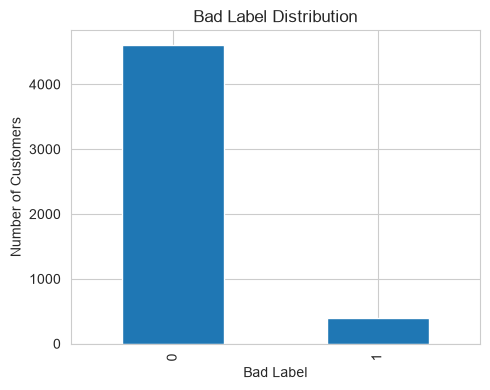

In [5]:
# Target distribution
bad_rate = demo["Bad_label"].mean()

print(f"Bad_label positive rate: {bad_rate:.2%}")

plt.figure(figsize=(5, 4))
demo["Bad_label"].value_counts().plot(kind="bar")
plt.title("Bad Label Distribution")
plt.xlabel("Bad Label")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [6]:
acct_per_cust = acct.groupby("customer_no").size()

print(f"Average accounts per customer: {acct_per_cust.mean():.2f}")
print(f"Maximum accounts per customer: {acct_per_cust.max()}")

Average accounts per customer: 1.99
Maximum accounts per customer: 3


Accounts with past-due amount: 25.0%


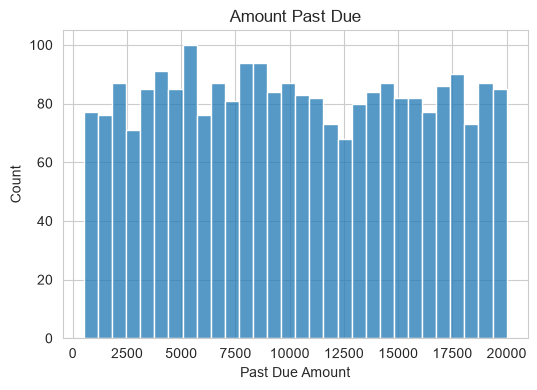

In [7]:
past_due_rate = (acct["amt_past_due"] > 0).mean()

print(f"Accounts with past-due amount: {past_due_rate:.1%}")

plt.figure(figsize=(6, 4))
sns.histplot(
    acct.loc[acct["amt_past_due"] > 0, "amt_past_due"],
    bins=30
)
plt.title("Amount Past Due")
plt.xlabel("Past Due Amount")
plt.show()

In [8]:
enq_per_cust = enq.groupby("customer_no").size()

print(f"Average enquiries per customer: {enq_per_cust.mean():.2f}")
print(f"Maximum enquiries per customer: {enq_per_cust.max()}")

Average enquiries per customer: 3.99
Maximum enquiries per customer: 7


In [11]:
feature_cols = [
    c for c in demo.columns
    if c.startswith("feature_")
]

corr = demo[feature_cols + ["Bad_label"]].corr()["Bad_label"]
corr = corr.drop("Bad_label").abs().sort_values(ascending=False)

print("Top correlated features:")
print(corr.head(10))

Top correlated features:
feature_1     0.271731
feature_2     0.163571
feature_5     0.125344
feature_40    0.034089
feature_33    0.033984
feature_47    0.033480
feature_25    0.031866
feature_22    0.031704
feature_71    0.028544
feature_35    0.028357
Name: Bad_label, dtype: float64


In [10]:
DPD_BUCKET_RE = re.compile(r"\d{3}|XXX")

def _parse_dpd_blocks(payment_str):
    if not isinstance(payment_str, str):
        return []
    return [b for b in DPD_BUCKET_RE.findall(payment_str) if b != "XXX"]

def _avg_dpd_0_29(payment_str):
    blocks = _parse_dpd_blocks(payment_str)
    if not blocks:
        return np.nan
    return float(np.mean([1 if b == "000" else 0 for b in blocks]))

def _min_months_to_30_plus(payment_str):
    blocks = _parse_dpd_blocks(payment_str)
    for i, b in enumerate(blocks):
        if b != "000":
            try:
                if int(b) >= 30:
                    return i + 1
            except ValueError:
                continue
    return np.nan

def _payment_history_length(payment_str):
    return len(_parse_dpd_blocks(payment_str))

print("Payment-history parsing helpers ready.")


Payment-history parsing helpers ready.


In [12]:
def build_account_features(acct):

    acct = acct.copy()

    acct["opened_dt"] = pd.to_datetime(
        acct["opened_dt"], errors="coerce"
    )

    acct["last_paymt_dt"] = pd.to_datetime(
        acct["last_paymt_dt"], errors="coerce"
    )

    acct["account_age_days"] = (
        acct["last_paymt_dt"] - acct["opened_dt"]
    ).dt.days

    acct["ph_avg_dpd_0_29"] = (
        acct["paymenthistory1"].apply(_avg_dpd_0_29)
    )

    acct["ph_min_months_30_plus"] = (
        acct["paymenthistory1"].apply(_min_months_to_30_plus)
    )

    acct["ph_length"] = (
        acct["paymenthistory1"].apply(_payment_history_length)
    )

    return acct

In [13]:
acct = build_account_features(acct)

acct_feats = acct.groupby("customer_no").agg(
    total_account_age=("account_age_days", "sum"),
    mean_account_age=("account_age_days", "mean"),
    payment_history_avg_dpd=("ph_avg_dpd_0_29", "mean"),
    min_months_30_plus=("ph_min_months_30_plus", "min"),
    payment_history_length=("ph_length", "mean"),
    total_balance=("cur_balance_amt", "sum"),
    mean_balance=("cur_balance_amt", "mean"),
    total_credit_limit=("creditlimit", "sum"),
    mean_credit_limit=("creditlimit", "mean"),
    mean_cash_limit=("cashlimit", "mean"),
    number_of_accounts=("acct_type", "count"),
    total_past_due=("amt_past_due", "sum")
).reset_index()

acct_feats["credit_utilisation"] = (
    acct_feats["total_balance"] /
    acct_feats["total_credit_limit"].replace(0, np.nan)
)

print("Account features:", acct_feats.shape)

Account features: (5000, 14)


In [14]:
def build_enquiry_features(enq, as_of="2024-01-01"):

    enq = enq.copy()

    enq["enquiry_dt"] = pd.to_datetime(
        enq["enquiry_dt"], errors="coerce"
    )

    as_of = pd.Timestamp(as_of)

    enq["days_since_enquiry"] = (
        as_of - enq["enquiry_dt"]
    ).dt.days

    features = enq.groupby("customer_no").agg(
        enquiry_365_days=(
            "days_since_enquiry",
            lambda x: (x <= 365).sum()
        ),
        enquiry_90_days=(
            "days_since_enquiry",
            lambda x: (x <= 90).sum()
        ),
        total_enquiries=("enq_purpose", "count")
    ).reset_index()

    return features

In [15]:
enq_feats = build_enquiry_features(enq)

print("Enquiry features:", enq_feats.shape)

Enquiry features: (4378, 4)


In [18]:
feature_df = demo.merge(
    acct_feats,
    on="customer_no",
    how="left"
)

feature_df = feature_df.merge(
    enq_feats,
    on="customer_no",
    how="left"
)

# Fill missing values in engineered features
numeric_cols = feature_df.select_dtypes(
    include=np.number
).columns

feature_df[numeric_cols] = feature_df[numeric_cols].fillna(0)

print("Final feature matrix:", feature_df.shape)

feature_df.head()

Final feature matrix: (5000, 97)


,customer_no,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,mean_balance,total_credit_limit,mean_credit_limit,mean_cash_limit,number_of_accounts,total_past_due,credit_utilisation,enquiry_365_days,enquiry_90_days,total_enquiries
0,CUST100000,-0.8386,-0.4229,-0.6950,1.9887,0.0533,0.0231,-0.9582,-0.5906,-1.9900,...,37670.94,214497.96,214497.96,39255.72,1,19524.64,0.175624,0.0,0.0,5.0
1,CUST100001,1.5068,-0.4500,-0.0058,0.1617,-1.1896,0.0562,0.1987,-1.0688,-1.8779,...,226094.44,98727.42,98727.42,29381.76,1,0.00,2.290088,0.0,0.0,4.0
2,CUST100002,1.5417,-0.1246,-0.2871,-0.2226,-0.3798,0.6743,0.3594,-0.3887,-0.4406,...,233639.19,94366.17,94366.17,26237.80,1,0.00,2.475879,0.0,0.0,3.0
3,CUST100003,-0.6919,-1.2738,-3.1375,-0.0676,1.0866,0.1700,-2.1307,0.4592,0.3297,...,356670.91,193852.78,193852.78,6188.97,1,0.00,1.839906,0.0,0.0,5.0
4,CUST100004,-0.8695,-1.0627,-0.2728,-0.1361,-0.1481,1.8035,0.3794,0.1839,1.6186,...,186952.64,24283.69,24283.69,19307.09,1,15802.89,7.698692,0.0,0.0,4.0


In [19]:
ID_COL = "customer_no"
TARGET_COL = "Bad_label"

X = feature_df.drop(
    columns=[ID_COL, TARGET_COL]
)

y = feature_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3750
Testing samples: 1250


In [20]:
pos_rate = y_train.mean()

scale_pos_weight = (
    (1 - pos_rate) / pos_rate
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

joblib.dump(
    model,
    "outputs/model.pkl"
)

print("Model training completed.")

Model training completed.


In [21]:
gain_dict = model.get_booster().get_score(
    importance_type="gain"
)

importance = pd.DataFrame(
    [
        {
            "Feature": feature,
            "Gain": gain_dict.get(feature, 0)
        }
        for feature in X_train.columns
    ]
).sort_values(
    "Gain",
    ascending=False
)

importance.head(15)

,Feature,Gain
0,feature_1,94.851959
1,feature_2,50.963608
4,feature_5,39.583214
39,feature_40,26.967888
78,feature_79,26.939676
33,feature_34,23.605524
88,mean_cash_limit,22.544714
52,feature_53,22.237501
82,min_months_30_plus,21.599634
81,payment_history_avg_dpd,21.480394


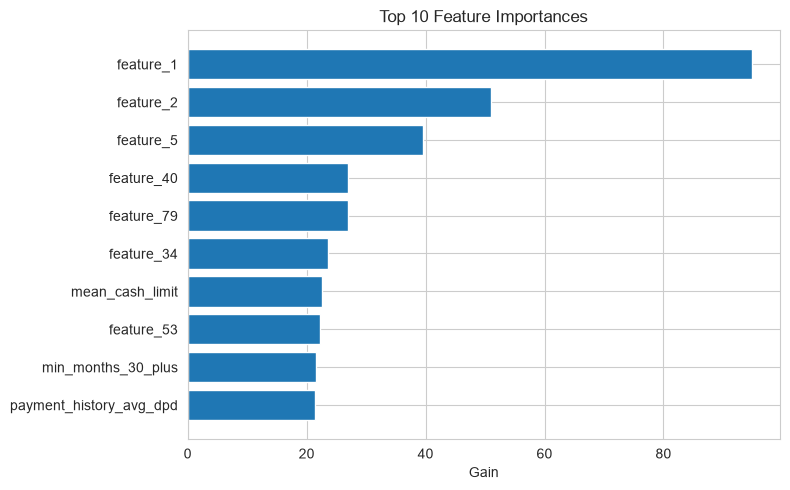

In [22]:
top_features = importance.head(10).sort_values("Gain")

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["Feature"],
    top_features["Gain"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

In [23]:
test_probs = model.predict_proba(X_test)[:, 1]

test_out = X_test.copy()
test_out[TARGET_COL] = y_test.values
test_out["predicted_prob"] = test_probs

test_out.to_csv(
    "outputs/test_predictions.csv",
    index=False
)

test_out[[TARGET_COL, "predicted_prob"]].head()

,Bad_label,predicted_prob
1812,0,0.007226
4264,0,0.314416
2205,0,0.004331
4895,0,0.001828
2917,0,0.010621


In [31]:
BENCHMARK_GINI = 37.9

def gini_from_auc(auc):
    return (2 * auc - 1) * 100

auc = roc_auc_score(
    y_test,
    test_probs
)

gini = gini_from_auc(auc)

print(f"AUC  : {auc:.4f}")
print(f"Gini : {gini:.2f}")
print(f"Benchmark Gini: {BENCHMARK_GINI}")
print("Result:", "BEATS the benchmark ✅" if gini > BENCHMARK_GINI else "BELOW the benchmark ⚠️")

AUC  : 0.7893
Gini : 57.86
Benchmark Gini: 37.9
Result: BEATS the benchmark ✅


In [26]:
if gini > BENCHMARK_GINI:
    print("Model beats the benchmark.")
else:
    print("Model is below the benchmark.")

Model beats the benchmark.


In [27]:
def decile_rank_order(df, prob_col="predicted_prob", target_col=TARGET_COL):
    df = df.copy()
    df["decile"] = pd.qcut(df[prob_col].rank(method="first"), 10, labels=False) + 1
    total_bads = df[target_col].sum()

    table = (
        df.groupby("decile")[target_col].sum()
        .reindex(range(1, 11), fill_value=0)
        .rename("bad_count").to_frame()
    )
    table["pct_of_total_bads"] = table["bad_count"] / max(total_bads, 1) * 100
    table["bad_rate_in_decile"] = (
        df.groupby("decile")[target_col].mean().reindex(range(1, 11), fill_value=0) * 100
    )
    return table.sort_index(ascending=False)  # decile 10 (highest risk) first

rank_table = decile_rank_order(test_out)
rank_table


,bad_count,pct_of_total_bads,bad_rate_in_decile
decile,,,
10,35,35.0,28.0
9,24,24.0,19.2
8,13,13.0,10.4
7,7,7.0,5.6
6,4,4.0,3.2
5,8,8.0,6.4
4,4,4.0,3.2
3,2,2.0,1.6
2,2,2.0,1.6


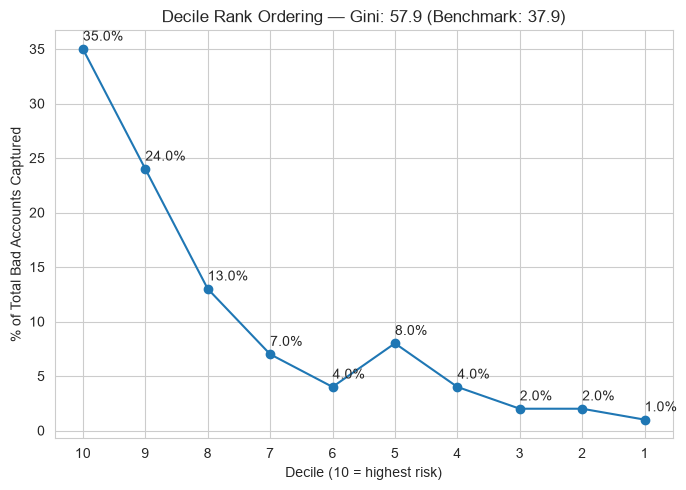

In [28]:
plt.figure(figsize=(7, 5))
x = rank_table.index.astype(str)
y = rank_table["pct_of_total_bads"]
plt.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    plt.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points", xytext=(0, 6))
plt.title(f"Decile Rank Ordering — Gini: {gini:.1f} (Benchmark: {BENCHMARK_GINI})")
plt.xlabel("Decile (10 = highest risk)")
plt.ylabel("% of Total Bad Accounts Captured")
plt.tight_layout()
plt.savefig("outputs/decile_rank_order.png")
plt.show()


In [29]:
report = f"""
Credit Risk Model Evaluation
----------------------------

Test samples : {len(test_out):,}
AUC          : {auc:.4f}
Gini         : {gini:.2f}
Benchmark    : {BENCHMARK_GINI:.2f}

The model was evaluated using AUC, Gini coefficient
and decile rank ordering.
"""

with open(
    "outputs/evaluation_report.txt",
    "w"
) as f:
    f.write(report)

print(report)


Credit Risk Model Evaluation
----------------------------

Test samples : 1,250
AUC          : 0.7893
Gini         : 57.86
Benchmark    : 37.90

The model was evaluated using AUC, Gini coefficient
and decile rank ordering.



## Business Interpretation

The developed model can support banking decision-making by identifying customers according to their predicted credit risk.

Potential applications include:

- Prioritizing high-risk customers for additional review.
- Supporting loan underwriting decisions.
- Identifying customers requiring additional verification.
- Monitoring customers with potentially risky credit behaviour.
- Improving the efficiency of manual credit assessment.

The model should be considered a decision-support tool rather than a replacement for human credit assessment.

---

## Limitations

The project has several limitations:

1. Model performance depends on the quality and representativeness of the available data.
2. Historical patterns may not always represent future customer behaviour.
3. The synthetic fallback dataset is intended only for development and testing and should not be used as evidence of real-world model performance.
4. The model does not automatically account for changes in economic conditions.
5. Feature importance does not necessarily imply a causal relationship between a feature and default risk.
6. Additional validation would be required before deploying the model in a production banking environment.

---


## Future Improvements

The project can be extended in several ways:

- Perform systematic hyperparameter tuning.
- Compare XGBoost with LightGBM and Logistic Regression.
- Add model explainability using SHAP.
- Perform probability calibration.
- Introduce time-based validation.
- Monitor model performance after deployment.
- Add additional credit-history features.
- Develop a simple dashboard for risk monitoring.
- Implement automated data and model pipelines.

These improvements can be considered for a production-level implementation but are not necessary for the basic internship submission.

---

## Conclusion

This project demonstrates an end-to-end machine learning approach for banking credit-risk prediction.

Customer account, enquiry, and demographic information were combined to create meaningful customer-level features. Exploratory analysis was performed to understand the data, followed by feature engineering and class-imbalance handling.

An XGBoost classification model was trained to predict bad-risk customers. Its performance was evaluated using ROC-AUC and the Gini coefficient, followed by decile-based risk ranking to assess the model's ability to identify high-risk customers.

Overall, the project demonstrates practical knowledge of data extraction, data preprocessing, exploratory analysis, feature engineering, machine learning, model evaluation, and business-oriented risk analysis, making it suitable as an internship-level machine learning project.